# (PA)CBED simulation
This notebook takes you through a simple CBED simulation for the same crystal used in the thesis and creates a RGB overlay to compare the differences.
Feel free to play around with the simulation parameters like the electron energy. This notebook also does a PACBED scan and compares the different models for that as well.
```{warning}
**Caution!**
This simulation requires some processing power to work and is therefore not suitable to run here in the browser. 
If you want to test out this notebook it is recommended to download the notebook and run it locally instead.
There is also the multislice_fast notebook which runs perfectly fine in the browser.

In [1]:
import abtem
import ase
import matplotlib.pyplot as plt
import numpy as np

In [2]:
STO_crystal = ase.Atoms(
    "SrTiO3",
    scaled_positions=[
        (0.0, 0.0, 0.0),

        (0.5, 0.5, 0.5),

        (0.5, 0.0, 0.5),
        (0.5, 0.5, 0.0),
        (0.0, 0.5, 0.5),
    ],
    cell=[3.91270131, 3.91270131, 3.91270131, 90, 90, 90],
    pbc=True
)
STO_orthorhombic = abtem.orthogonalize_cell(STO_crystal)

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='y [Å]', ylabel='z [Å]'>)

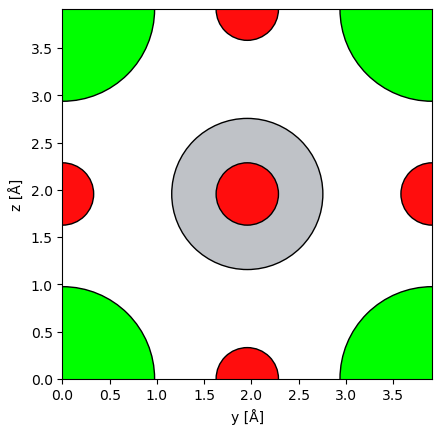

In [3]:
abtem.show_atoms(STO_orthorhombic,plane='yz',scale=0.5,tight_limits=True,show_periodic=True)

In [4]:
sampling = 0.1 #Angstrom
slice_thickness = 0.5 #Angstrom
thickness = 48 #unit cells 
sample_size = (12,12,thickness)
energy = 20e3 #eV
semiangle=20

In [ ]:
unit_cell_potential = abtem.Potential(
            STO_orthorhombic,
            sampling=sampling,
            parametrization="lobato",
            slice_thickness=slice_thickness,
            projection="finite",
            # device='gpu'
        )

potential = abtem.CrystalPotential(
    unit_cell_potential,
    repetitions=sample_size,
)

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

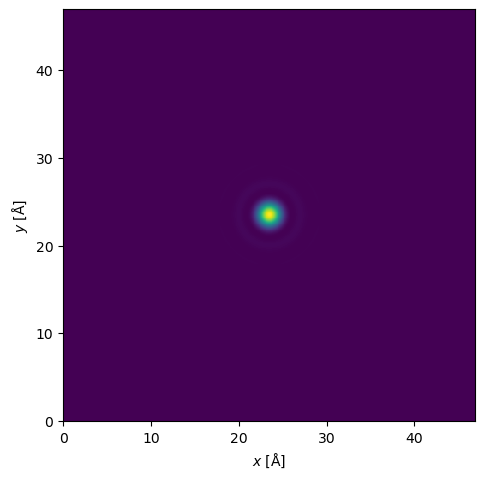

In [ ]:
probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle,
    # device='gpu'
).match_grid(potential)

probe.show()

In [7]:
from abtem.multislice import RealSpaceMultislice 

detector = abtem.PixelatedDetector(max_angle=None)

CMS = RealSpaceMultislice()
PCMS = RealSpaceMultislice(
    order = 3,
)
FCMS = RealSpaceMultislice(
    order = 3,
    expansion_scope='full'
)

In [8]:
exitwave_cms = probe.multislice(potential=potential,detectors=detector, algorithm = CMS,pbar=True,lazy=False)

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

In [9]:
exitwave_pcms = probe.multislice(potential=potential,detectors=detector, algorithm = PCMS,pbar=True,lazy=False)

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

In [10]:
exitwave_fcms = probe.multislice(potential=potential,detectors=detector, algorithm = FCMS,pbar=True,lazy=False)

multislice:   0%|          | 0/384 [00:00<?, ?it/s]

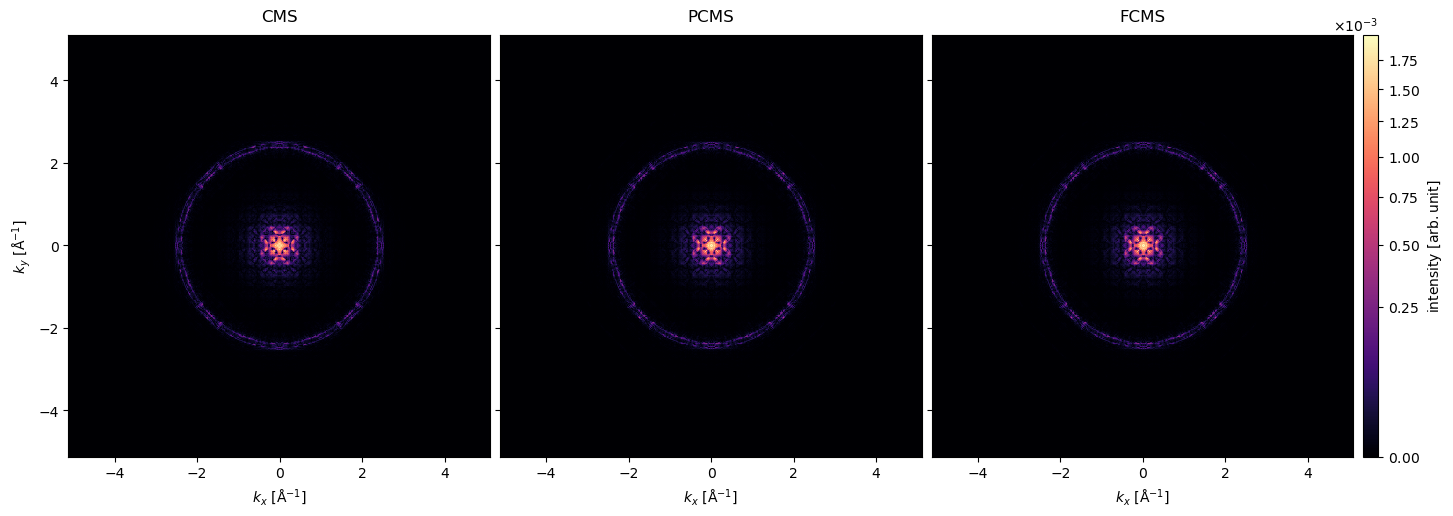

In [11]:
all_exitwaves = abtem.stack(
    (
        exitwave_cms,
        exitwave_pcms,
        exitwave_fcms
    ),
    (
        'CMS',
        'PCMS',
        'FCMS'
    )
)

all_exitwaves.show(
    explode = True,
    cbar=True,
    cmap='magma',
    figsize=(16, 9),
    vmin=0,
    common_color_scale=True,
    power=0.5
)

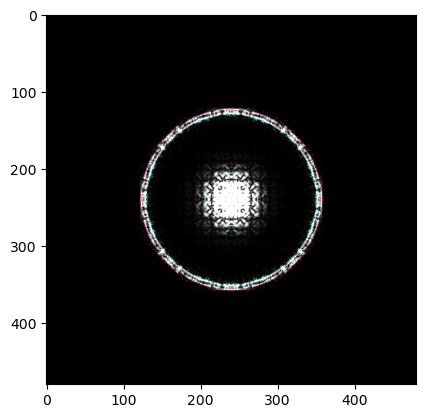

In [12]:
threshold = 0.98

cms_array = exitwave_cms.array
R_quantile = np.quantile(cms_array, threshold)
cms_array = np.clip(cms_array, 0, R_quantile)
R = cms_array / cms_array.max()

pcms_array = exitwave_pcms.array
G_quantile = np.quantile(pcms_array, threshold)
pcms_array = np.clip(pcms_array, 0, G_quantile)
G = pcms_array / pcms_array.max()

fcms_array = exitwave_fcms.array
B_quantile = np.quantile(fcms_array, threshold)
fcms_array = np.clip(fcms_array, 0, B_quantile)
B = fcms_array / fcms_array.max()

rgb_image = np.stack([R, G, B], axis=-1)
plt.imshow(rgb_image, vmin=0)


# PACBED
```{note} This simulation takes quite long dependend on the machine used. Calculating on a GPU is highly recommended  
```

Here we perform a PACBED scan for a higher electron energy and plot the relative difference between the PCMS/FCMS and the CMS as explained in Section. @STEM.

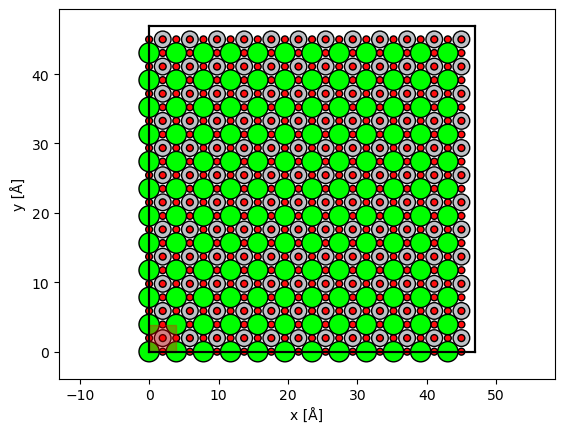

In [13]:
haadf = abtem.AnnularDetector(inner=25, outer=None)

probe = abtem.Probe(energy=200e3, semiangle_cutoff=semiangle, device='gpu').match_grid(potential)

grid_scan = abtem.GridScan(
    start=[0, 0],
    end=(STO_orthorhombic.cell[0,0]*1, STO_orthorhombic.cell[1,1]*1),
    sampling=probe.aperture.nyquist_sampling,
    potential=potential,
)

fig, ax = abtem.show_atoms(STO_orthorhombic*(12,12,1))
grid_scan.add_to_plot(ax)

In [14]:
measurements_cms = probe.scan(potential, scan=grid_scan, detectors=haadf, lazy=False, algorithm=CMS, pbar=True)

multislice:   0%|          | 0/64896 [00:00<?, ?it/s]

In [15]:
measurements_pcms = probe.scan(potential, scan=grid_scan, detectors=haadf, lazy=False, algorithm=PCMS, pbar=True)

multislice:   0%|          | 0/64896 [00:00<?, ?it/s]

In [16]:
measurements_fcms = probe.scan(potential, scan=grid_scan, detectors=haadf, lazy=False, algorithm=FCMS, pbar=True)

multislice:   0%|          | 0/64896 [00:00<?, ?it/s]

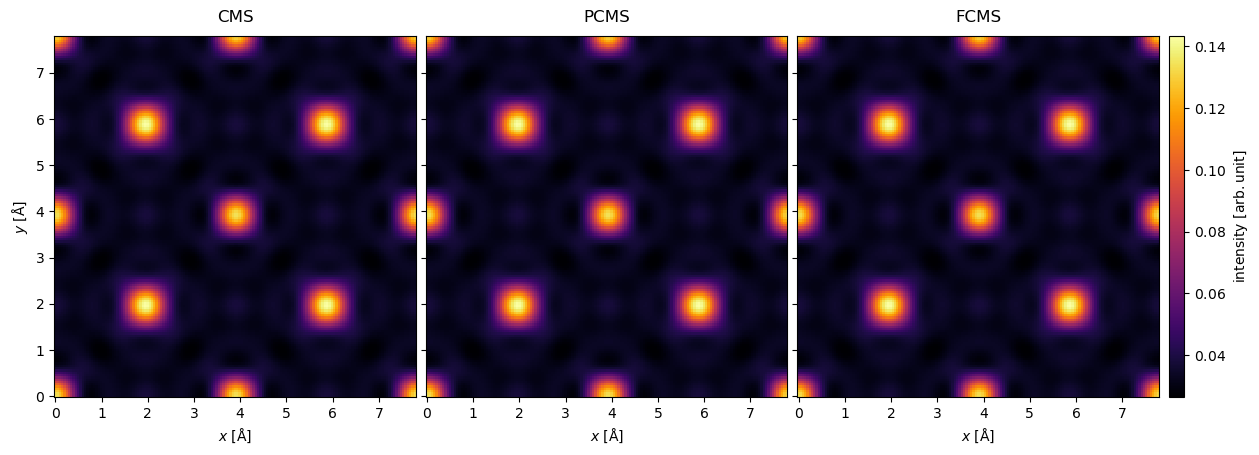

In [17]:
interpolation_value = 0.05

all_exitwaves = abtem.stack(
    (
        measurements_cms.tile((2,2)).interpolate(sampling=interpolation_value),
        measurements_pcms.tile((2,2)).interpolate(sampling=interpolation_value),
        measurements_fcms.tile((2,2)).interpolate(sampling=interpolation_value)
    ),
    (
        'CMS',
        'PCMS',
        'FCMS'
    )
)

all_exitwaves.show(
    explode = True,
    cbar=True,
    cmap='inferno',
    figsize=(14, 8),
    common_color_scale=True,
)

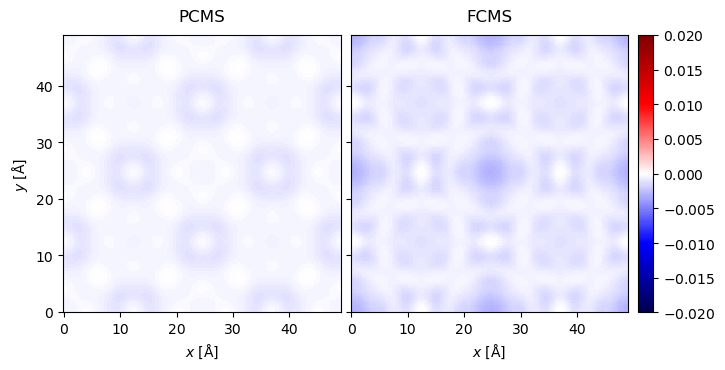

In [18]:
from abtem.measurements import Images

diff_rel_pcms = (measurements_pcms.tile((2,2)).interpolate(sampling=interpolation_value).array - measurements_cms.tile((2,2)).interpolate(sampling=interpolation_value).array) / (1e-6 + measurements_cms.tile((2,2)).interpolate(sampling=interpolation_value).array)
diff_rel_fcms = (measurements_fcms.tile((2,2)).interpolate(sampling=interpolation_value).array - measurements_cms.tile((2,2)).interpolate(sampling=interpolation_value).array) / (1e-6 + measurements_cms.tile((2,2)).interpolate(sampling=interpolation_value).array)

diff_rel_pcms_img = Images(array = diff_rel_pcms, sampling=probe.aperture.nyquist_sampling)
diff_rel_fcms_img = Images(array = diff_rel_fcms, sampling=probe.aperture.nyquist_sampling)

all_measurements = abtem.stack(
    (
        diff_rel_pcms_img,
        diff_rel_fcms_img
    ),
    (
        'PCMS',
        'FCMS'
    )
)

all_measurements.show(
    cmap='seismic', 
    vmin=-0.02, 
    vmax=0.02, 
    explode=True, 
    figsize=(8, 5),
    common_color_scale=True,
    cbar=True
)